In [2]:
import os
import pandas as pd
import numpy as np
from rapidfuzz import fuzz
from tqdm.auto import tqdm
from pipeline import EntityResolutionPipeline

# 1. Load sample data
er = EntityResolutionPipeline(sample_size=50000)
er.load_and_sample()

sample_s1 = er.sample_s1
sample_s2 = er.sample_s2
sample_s3 = er.sample_s3
sample_gt = er.sample_gt

# 2. Build fast lookups
print("Building fast dictionary lookups...")
s1_name_dict = sample_s1.set_index('entity_id')['clean_name'].to_dict()
s1_addr_dict = sample_s1.set_index('entity_id')['clean_address'].to_dict()
s1_country_dict = sample_s1.set_index('entity_id')['country'].to_dict()

cand_pool = pd.concat([sample_s2, sample_s3]).drop_duplicates(subset=['entity_id'])
cand_name_dict = cand_pool.set_index('entity_id')['clean_name'].to_dict()
cand_addr_dict = cand_pool.set_index('entity_id')['clean_address'].to_dict()
cand_countries = cand_pool.groupby('country')['entity_id'].apply(list).to_dict()

# 3. Generate candidate pairs
np.random.seed(42)
pairs = []

for _, row in tqdm(sample_gt.iterrows(), total=len(sample_gt), desc="Generating Pairs"):
    s1_id = row['source1_entity_id']
    s1_country = s1_country_dict.get(s1_id)
    
    raw_matches = row['matched_entity_ids']
    true_matches = [m.strip() for m in str(raw_matches).split(',') if m.strip()] if pd.notna(raw_matches) else []
    
    for match_id in true_matches:
        if match_id in cand_name_dict:
            pairs.append({'s1_id': s1_id, 'cand_id': match_id, 'label': 1})
            
    if s1_country and s1_country in cand_countries:
        country_cands = cand_countries[s1_country]
        possible_negatives = list(set(country_cands) - set(true_matches))
        if possible_negatives:
            neg_samples = np.random.choice(possible_negatives, size=min(3, len(possible_negatives)), replace=False)
            for neg_id in neg_samples:
                pairs.append({'s1_id': s1_id, 'cand_id': neg_id, 'label': 0})

pairs_df = pd.DataFrame(pairs)

# 4. High-Speed Zip Feature Extraction
s1_ids = pairs_df['s1_id'].values
cand_ids = pairs_df['cand_id'].values
features = []

for s1_id, cand_id in tqdm(zip(s1_ids, cand_ids), total=len(pairs_df), desc="Computing Features"):
    s1_name = str(s1_name_dict.get(s1_id, ''))
    s1_addr = str(s1_addr_dict.get(s1_id, ''))
    cand_name = str(cand_name_dict.get(cand_id, ''))
    cand_addr = str(cand_addr_dict.get(cand_id, ''))
    
    name_exact = int(s1_name == cand_name and s1_name != "")
    name_ratio = fuzz.ratio(s1_name, cand_name)
    name_token_sort = fuzz.token_sort_ratio(s1_name, cand_name)
    
    addr_exact = int(s1_addr == cand_addr and s1_addr != "")
    addr_ratio = fuzz.ratio(s1_addr, cand_addr) if s1_addr and cand_addr else 0
    addr_token_set = fuzz.token_set_ratio(s1_addr, cand_addr) if s1_addr and cand_addr else 0
    
    features.append((name_exact, name_ratio, name_token_sort, addr_exact, addr_ratio, addr_token_set))

feature_cols = ['name_exact', 'name_ratio', 'name_token_sort', 'addr_exact', 'addr_ratio', 'addr_token_set']
features_df = pd.DataFrame(features, columns=feature_cols)
pairs_df = pd.concat([pairs_df, features_df], axis=1)

# 5. Save directly to work/ directory
os.makedirs("work", exist_ok=True)
pairs_df.to_parquet("work/features_50k.parquet", index=False)
print("Saved feature matrix to work/features_50k.parquet!")


Resolving dataset paths...
Loading datasets...
Creating 50000-entity sample...
Cleaning text strings...
Data loaded, sampled, and cleaned successfully!
Building fast dictionary lookups...


Generating Pairs:   0%|          | 0/50000 [00:00<?, ?it/s]

Computing Features:   0%|          | 0/322784 [00:00<?, ?it/s]

Saved feature matrix to work/features_50k.parquet!


=== STEP 1: LOADING DATASET FROM DISK ===
Loaded 322,784 pairs successfully into Train.ipynb!
Train pairs: 258,288
Validation pairs: 64,496

=== STEP 2: TRAINING LIGHTGBM MODEL ===
Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.0489369
[100]	valid_0's binary_logloss: 0.0124841
[150]	valid_0's binary_logloss: 0.00981925
[200]	valid_0's binary_logloss: 0.00978515
Early stopping, best iteration is:
[177]	valid_0's binary_logloss: 0.009716

=== STEP 3: OPTIMIZING GLOBAL THRESHOLD FOR F0.5 ===
Threshold: 0.10 | Precision: 0.9918 | Recall: 0.9991 | F0.5: 0.9933
Threshold: 0.15 | Precision: 0.9930 | Recall: 0.9987 | F0.5: 0.9942
Threshold: 0.20 | Precision: 0.9941 | Recall: 0.9987 | F0.5: 0.9950
Threshold: 0.25 | Precision: 0.9947 | Recall: 0.9983 | F0.5: 0.9954
Threshold: 0.30 | Precision: 0.9955 | Recall: 0.9979 | F0.5: 0.9959
Threshold: 0.35 | Precision: 0.9959 | Recall: 0.9975 | F0.5: 0.9962
Threshold: 0.40 | Precision: 0.9962 | Recall: 0.997

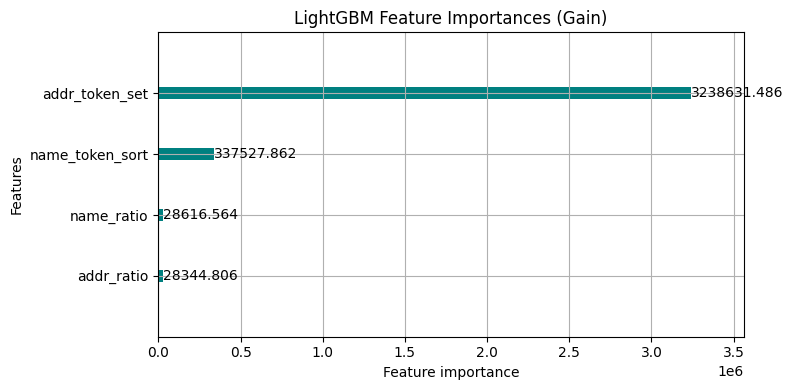

In [4]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import precision_recall_fscore_support

print("=== STEP 1: LOADING DATASET FROM DISK ===")
pairs_df = pd.read_parquet("work/features_50k.parquet")
print(f"Loaded {len(pairs_df):,} pairs successfully into Train.ipynb!")

# Prepare features and labels
feature_cols = ['name_exact', 'name_ratio', 'name_token_sort', 'addr_exact', 'addr_ratio', 'addr_token_set']
X = pairs_df[feature_cols]
y = pairs_df['label']
groups = pairs_df['s1_id']

# Group split by s1_id to prevent entity leakage between train and validation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

print(f"Train pairs: {len(X_train):,}")
print(f"Validation pairs: {len(X_val):,}")

# Initialize LightGBM Datasets
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

print("\n=== STEP 2: TRAINING LIGHTGBM MODEL ===")
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1 # Uses all M1 cores
}

model = lgb.train(
    params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

print("\n=== STEP 3: OPTIMIZING GLOBAL THRESHOLD FOR F0.5 ===")
val_probs = model.predict(X_val)

# Save predictions to the validation dataframe for Stage 4 later
val_results = pairs_df.iloc[val_idx].copy()
val_results['pred_prob'] = val_probs

best_f05 = 0.0
best_thresh = 0.5

for thresh in np.arange(0.1, 0.96, 0.05):
    preds = (val_probs >= thresh).astype(int)
    p, r, f05, _ = precision_recall_fscore_support(y_val, preds, beta=0.5, average='binary', zero_division=0)
    print(f"Threshold: {thresh:.2f} | Precision: {p:.4f} | Recall: {r:.4f} | F0.5: {f05:.4f}")
    
    if f05 > best_f05:
        best_f05 = f05
        best_thresh = thresh

print(f"OPTIMAL GLOBAL THRESHOLD: {best_thresh:.2f} with F0.5 Score: {best_f05:.4f}")

# Plot Feature Importance
lgb.plot_importance(model, importance_type='gain', max_num_features=10, figsize=(8, 4), color='teal')
plt.title("LightGBM Feature Importances (Gain)")
plt.tight_layout()
plt.show()
